<a href="https://colab.research.google.com/github/Leticiamendes0/https-github.com-evertonesaa-calculo-numerico-computacional-2026/blob/main/Atividade_aula05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# Função
def f(x):
    return np.exp(-x) - x

# Derivada (para Newton)
def df(x):
    return -np.exp(-x) - 1

# -------------------------
# Método da Bissecção
# -------------------------
def bisseccao(a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) >= 0:
        print("Intervalo inválido!")
        return None

    iteracoes = 0
    while (b - a)/2 > tol and iteracoes < max_iter:
        c = (a + b) / 2
        if f(c) == 0:
            return c, iteracoes
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
        iteracoes += 1

    return (a + b) / 2, iteracoes

# -------------------------
# Método de Newton
# -------------------------
def newton(x0, tol=1e-6, max_iter=100):
    iteracoes = 0
    x = x0

    while abs(f(x)) > tol and iteracoes < max_iter:
        x = x - f(x)/df(x)
        iteracoes += 1

    return x, iteracoes

# -------------------------
# Método da Secante
# -------------------------
def secante(x0, x1, tol=1e-6, max_iter=100):
    iteracoes = 0

    while abs(f(x1)) > tol and iteracoes < max_iter:
        x2 = x1 - f(x1)*(x1 - x0)/(f(x1) - f(x0))
        x0, x1 = x1, x2
        iteracoes += 1

    return x1, iteracoes

# -------------------------
# Executando os métodos
# -------------------------

# Bissecção (intervalo onde há troca de sinal)
raiz_bis, it_bis = bisseccao(0, 1)

# Newton (chute inicial)
raiz_newton, it_newton = newton(0.5)

# Secante (dois chutes iniciais)
raiz_sec, it_sec = secante(0, 1)

# -------------------------
# Resultados
# -------------------------
print("Resultados:\n")
print(f"Bissecção: raiz = {raiz_bis:.6f}, iterações = {it_bis}")
print(f"Newton: raiz = {raiz_newton:.6f}, iterações = {it_newton}")
print(f"Secante: raiz = {raiz_sec:.6f}, iterações = {it_sec}")

Resultados:

Bissecção: raiz = 0.567143, iterações = 19
Newton: raiz = 0.567143, iterações = 2
Secante: raiz = 0.567143, iterações = 4


### PARTE 5- INVESTIGAÇÃO - Qual método converteu mais rapidamente?
      O método que convergiu mais rapidamente foi o método de Newton. Isso ocorre porque ele possui convergência quadrática, ou seja, o erro diminui muito rapidamente a cada iteração quando o chute inicial é correto.
### A secante sempre converge?
     Nem sempre, pois depende bastante dos chutes iniciais, se estiverem perto do valor da raiz converge rapidamente.
### Em quais situações o método de secagem pode falhar?
     Quando f (x1​) - f (x0​)é muito pequeno (divisão quase por zero; quando os chutes iniciais estão longe da raiz.
### Compare a necessidade de informação adicional entre os métodos:
     Bissecção:Precisa de um intervalo [𝑎,𝑏] com mudança de sinal; Não precisa de derivada; Mais simples e robusto.
     Newton: Precisa de um chute inicial x0​; Precisa da derivada da função; Mais rápido, porém exige mais informação.
     Secante: Precisa de dois chutes iniciais; Não precisa da derivada; Intermediário entre bissecção e Newton.
### Se você estava desenvolvendo um software de engenharia para encontrar raízes de funções desconhecidas, qual método escolheria e por quê?
     Secante devido o bom equilíbrio entre rapidez e simplicidade.



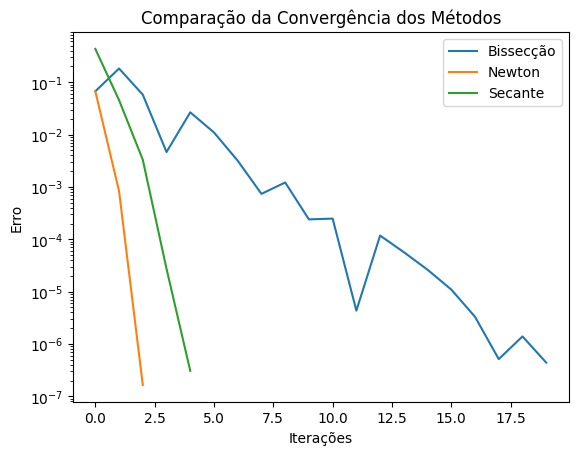

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Função
def f(x):
    return np.exp(-x) - x

# Derivada
def df(x):
    return -np.exp(-x) - 1

# Raiz aproximada (valor real)
x_real = 0.567143

# -------------------------
# Bissecção (com erro)
# -------------------------
def bisseccao(a, b, tol=1e-6, max_iter=100):
    erros = []
    for i in range(max_iter):
        c = (a + b) / 2
        erro = abs(c - x_real)
        erros.append(erro)

        if abs(f(c)) < tol:
            break

        if f(a)*f(c) < 0:
            b = c
        else:
            a = c

    return erros

# -------------------------
# Newton (com erro)
# -------------------------
def newton(x0, tol=1e-6, max_iter=100):
    erros = []
    x = x0

    for i in range(max_iter):
        erro = abs(x - x_real)
        erros.append(erro)

        if abs(f(x)) < tol:
            break

        x = x - f(x)/df(x)

    return erros

# -------------------------
# Secante (com erro)
# -------------------------
def secante(x0, x1, tol=1e-6, max_iter=100):
    erros = []

    for i in range(max_iter):
        erro = abs(x1 - x_real)
        erros.append(erro)

        if abs(f(x1)) < tol:
            break

        x2 = x1 - f(x1)*(x1 - x0)/(f(x1) - f(x0))
        x0, x1 = x1, x2

    return erros

# -------------------------
# Executando
# -------------------------
erros_bis = bisseccao(0, 1)
erros_new = newton(0.5)
erros_sec = secante(0, 1)

# -------------------------
# Gráfico
# -------------------------
plt.figure()

plt.plot(erros_bis, label="Bissecção")
plt.plot(erros_new, label="Newton")
plt.plot(erros_sec, label="Secante")

plt.yscale("log")  # escala log para ver melhor
plt.xlabel("Iterações")
plt.ylabel("Erro")
plt.title("Comparação da Convergência dos Métodos")
plt.legend()

plt.show()

### DESAFIO EXTRA

O gráfico mostra que o erro do método da bissecção diminui lentamente, caracterizando convergência linear. O método da secante apresenta uma redução mais rápida do erro, indicando convergência superlinear. Já o método de Newton apresenta a queda mais acentuada do erro, confirmando sua convergência quadrática e maior eficiência.